# Notebook 1: Carga de Datos

**Objetivo:** cargar el dataset del S&P 500 (formato long), validar su integridad, pivotar a formato wide y exportar los parquets que consumirán los notebooks posteriores.

**Salidas generadas:**
- `closes.parquet` — precios close en formato wide (índice = fecha, columnas = tickers)
- `opens.parquet` — precios open en formato wide
- `sp500_membership.parquet` — pertenencia al S&P 500 en formato wide (1/0)
- `spy.parquet` — precios del benchmark SPY (Open y Close)

## 0) Imports y configuración

Librerías: `pandas`, `numpy`, `matplotlib`, `yfinance`.

Se resuelven las rutas al directorio `/data` de forma robusta.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

pd.set_option("display.max_columns", 50)

# ── Rutas ──
PROJECT_ROOT = Path.cwd().resolve()
# Subir niveles hasta encontrar la carpeta 'data'
while not (PROJECT_ROOT / "data").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PARQUET_SRC = DATA_DIR / "sp500_history.parquet"

# Archivos de salida
OUTPUT_FILES = {
    "closes": DATA_DIR / "closes.parquet",
    "opens": DATA_DIR / "opens.parquet",
    "membership": DATA_DIR / "sp500_membership.parquet",
    "spy": DATA_DIR / "spy.parquet",
}

RANDOM_SEED = 42

print(f"DATA_DIR:    {DATA_DIR}")
print(f"Parquet src: {PARQUET_SRC}")
print(f"Existe:      {PARQUET_SRC.exists()}")

DATA_DIR:    C:\Users\diego\MIAX\08-backtesting\data
Parquet src: C:\Users\diego\MIAX\08-backtesting\data\sp500_history.parquet
Existe:      True


## 1) Cargar datos

Primero reviso las columnas disponibles en el parquet para asegurarme de que tengo todo lo necesario.

Cargamos el parquet con las columnas esenciales para todo el proyecto: `date`, `symbol`, `open`, `close`, `in_sp500`, `volume` y `security_name`.

- `open` se necesita en NB4 (ventas a precio OPEN).
- `close` se usa para cálculos de momentum y compras.
- `in_sp500` controla el universo invertible en cada fecha (evita sesgo de supervivencia).
- `assetid` y `security_name` son útiles para identificar tickers con múltiples clases de acciones.

In [2]:
df_columns = pd.read_parquet(PARQUET_SRC).columns
print(f"Columnas en el parquet: {df_columns}")

Columnas en el parquet: Index(['date', 'symbol', 'assetid', 'security_name', 'sector', 'industry',
       'subsector', 'in_sp500', 'open', 'high', 'low', 'close', 'volume',
       'unadjusted_close'],
      dtype='object')


In [3]:
usecols = ["date", "symbol","volume","security_name", "open", "close", "in_sp500"]

df = pd.read_parquet(PARQUET_SRC, columns=usecols)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(f"Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

Shape: 7,250,110 filas × 7 columnas


,date,symbol,volume,security_name,open,close,in_sp500
0,1999-11-18,A,74862288.0,Agilent Technologies Inc Common,27.188307,25.545057,0
1,1999-11-19,A,18236110.0,Agilent Technologies Inc Common,25.657097,24.349968,0
2,1999-11-22,A,7874048.5,Agilent Technologies Inc Common,24.686087,26.067909,0
3,1999-11-23,A,7153099.0,Agilent Technologies Inc Common,25.395672,24.051195,0
4,1999-11-24,A,5797720.5,Agilent Technologies Inc Common,23.976501,24.536699,0


## 1.1) Descarga del benchmark (SPY)

Descargamos los precios de SPY vía yfinance para usarlo como benchmark en notebooks posteriores. Se guarda como parquet en `/data`.

In [4]:
print("Descargando SPY...")
spy_raw = yf.download("SPY", start=df["date"].min().date(), end=datetime.now(), auto_adjust=True)

spy = spy_raw[["Open", "Close"]].copy()
spy.columns = ["open", "close"]
spy.index.name = "date"

print(f"SPY shape: {spy.shape}")
spy.tail()

Descargando SPY...


[*********************100%***********************]  1 of 1 completed

SPY shape: (8327, 2)


,open,close
date,,
2026-02-23,687.830017,682.390015
2026-02-24,681.900024,687.349976
2026-02-25,690.179993,693.150024
2026-02-26,693.280029,689.299988
2026-02-27,683.090027,685.989990


## 2) Vista rápida del dataset

Confirmamos columnas, tipos de datos, tamaño y uso de memoria.

In [5]:
print("─── Tipos de datos ───")
print(df.dtypes)
print(f"\nShape:           {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Uso de memoria:  {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nValores nulos:\n{df.isnull().sum()}")

─── Tipos de datos ───
date             datetime64[ns]
symbol                   object
volume                  float32
security_name            object
open                    float32
close                   float32
in_sp500                  int32
dtype: object

Shape:           7,250,110 filas × 7 columnas
Uso de memoria:  1108.3 MB

Valores nulos:
date             0
symbol           0
volume           0
security_name    0
open             0
close            0
in_sp500         0
dtype: int64


## 3) Comprobaciones rápidas

Calculamos un resumen muy simple para validar el dataset:
- Rango de fechas y número de símbolos.
- Duplicados por `date` + `symbol`.
- Distribución de `in_sp500` para ver cuántas observaciones están dentro del índice.

In [6]:
# Rango de fechas y número de símbolos
print(f"Rango de fechas:    {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Símbolos únicos:    {df['symbol'].nunique()}")

# Duplicados por date + symbol
dupes = df.duplicated(subset=["date", "symbol"]).sum()
print(f"Duplicados (date+symbol): {dupes}")

# Distribución de in_sp500
print("\nDistribución in_sp500:")
print(df["in_sp500"].value_counts().rename({0: "Fuera del índice", 1: "En el índice"}))

Rango de fechas:    1990-01-02 → 2026-01-30
Símbolos únicos:    1289
Duplicados (date+symbol): 0

Distribución in_sp500:
in_sp500
En el índice        4555024
Fuera del índice    2695086
Name: count, dtype: int64


## 4) Pivoteo a formato wide

Filtramos a los activos que **en algún momento** tuvieron `in_sp500 == 1` y pivotamos a formato wide:
- Índice = `date`, columnas = tickers, valores = precio.
- Este formato permite cálculos vectorizados eficientes (momentum matricial, rebalanceos).

In [7]:
# Activos que alguna vez estuvieron en el S&P 500
symbols_ever_sp500 = df.loc[df["in_sp500"] == 1, "symbol"].unique()
df_sp = df[df["symbol"].isin(symbols_ever_sp500)].copy()

print(f"Activos con in_sp500=1 en algún momento: {len(symbols_ever_sp500)}")
print(f"Filas tras filtrar: {df_sp.shape[0]:,}")

Activos con in_sp500=1 en algún momento: 1289
Filas tras filtrar: 7,250,110


In [8]:
# Pivotar a formato wide
closes_wide = df_sp.pivot(index="date", columns="symbol", values="close").sort_index()
opens_wide = df_sp.pivot(index="date", columns="symbol", values="open").sort_index()
membership_wide = df_sp.pivot(index="date", columns="symbol", values="in_sp500").sort_index()

print(f"closes_wide:     {closes_wide.shape}")
print(f"opens_wide:      {opens_wide.shape}")
print(f"membership_wide: {membership_wide.shape}")
print(f"\n% NaN en closes: {closes_wide.isna().mean().mean() * 100:.1f}%")
print(f"% NaN en opens:  {opens_wide.isna().mean().mean() * 100:.1f}%")

closes_wide:     (9087, 1289)
opens_wide:      (9087, 1289)
membership_wide: (9087, 1289)

% NaN en closes: 38.1%
% NaN en opens:  38.1%


## 5) Guardar parquets en `/data`

Exportamos los 4 ficheros que consumirán los notebooks posteriores.

In [9]:
closes_wide.to_parquet(OUTPUT_FILES["closes"])
opens_wide.to_parquet(OUTPUT_FILES["opens"])
membership_wide.to_parquet(OUTPUT_FILES["membership"])
spy.to_parquet(OUTPUT_FILES["spy"])

print("Parquets guardados:")
for name, path in OUTPUT_FILES.items():
    size_mb = path.stat().st_size / 1e6
    print(f"  {name:12s} → {path.name:30s} ({size_mb:.1f} MB)")

Parquets guardados:
  closes       → closes.parquet                 (33.5 MB)
  opens        → opens.parquet                  (33.1 MB)
  membership   → sp500_membership.parquet       (0.8 MB)
  spy          → spy.parquet                    (0.2 MB)


## 6) Validación visual

Graficamos unas pocas acciones para comprobar que las series son coherentes en el tiempo, junto con SPY como referencia.

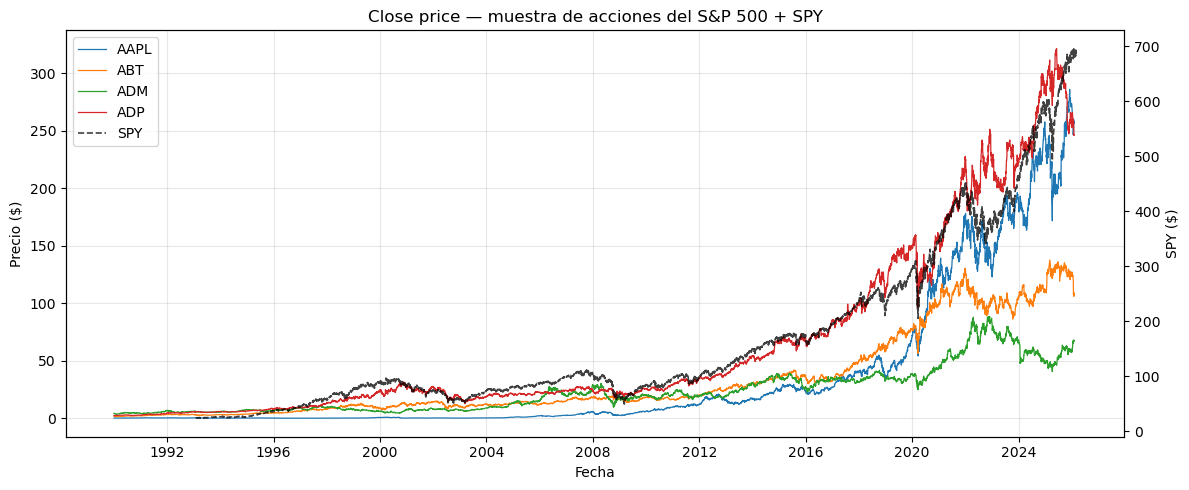

In [10]:
# Elegir 4 acciones con in_sp500=1 y más historia
symbols = (
    df[df["in_sp500"] == 1]
    .groupby("symbol")["date"].count()
    .nlargest(4)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 5))

for sym in symbols:
    sub = df[df["symbol"] == sym].sort_values("date")
    ax.plot(sub["date"], sub["close"], label=sym, linewidth=0.9)

# SPY en eje secundario
ax2 = ax.twinx()
ax2.plot(spy.index, spy["close"], label="SPY", color="black",
         linestyle="--", linewidth=1.2, alpha=0.75)
ax2.set_ylabel("SPY ($)")

# Combinar leyendas
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax.set_title("Close price — muestra de acciones del S&P 500 + SPY")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio ($)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()